In [71]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams.update({
    'figure.dpi': 100,
    'figure.figsize': (10, 6),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 2,
    'axes.labelsize': 15,
    'axes.labelcolor': 'black',
    'savefig.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'mathtext.fontset': 'cm',

    'savefig.bbox': 'tight',
    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,
})

In [72]:
data = np.loadtxt("./gvdP/20260512005.dat")

V_GS = data[:, 0]
I_GS = data[:, 1]
I_DS = data[:, 2]
V_DS = data[:, 3]
V_C = 0.5 * (data[:, 4] + data[:, 5])
V_12 = data[:, 6]
sigma = -np.log(2)/np.pi * (I_DS-I_GS) / V_12
V_del = -(V_GS - V_C)

# plt.plot(
#     V_del,
#     sigma * 1e6,
#     color='red',
#     marker='o',
#     markevery=1,
#     ls='-',
#     markeredgecolor="white", markeredgewidth=1, markersize=7
#     )

# plt.xlabel(r"$V_{GS} - V_C$ (V)")
# plt.ylabel(r"$\sigma$ ($\mu$S/sq.)")
# plt.title("Conductivity vs. Gate Voltage")
# plt.show()

C = 1.9e-9
A = 32e-6
Ci = C / A

Mobility (μ): 2.23 cm^2/Vs
Threshold Voltage (V_T): 8.85 V


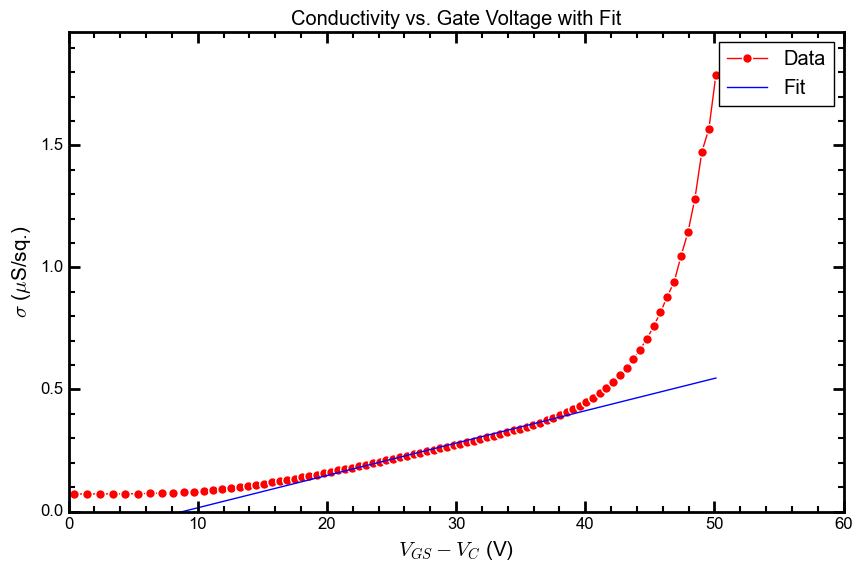

In [73]:
def func(x, a, b):
    return a*x + b

mask = (V_del > 20) & (V_del < 40)


popt, pcov = curve_fit(func, V_del[mask], sigma[mask])
sigma_fit = func(V_del, *popt)
a = popt[0]
b = popt[1]

mu = a / Ci * 1e4
V_T = -b / a

print(f"Mobility (μ): {mu:.2f} cm^2/Vs")
print(f"Threshold Voltage (V_T): {V_T:.2f} V")



# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))

plt.plot(
    V_del,
    sigma * 1e6,
    color='red',
    marker='o',
    markevery=1,
    ls='-',
    label='Data',
    markeredgecolor="white", markeredgewidth=1, markersize=7
    )
plt.plot(
    V_del,
    sigma_fit * 1e6,
    color='blue',
    ls='-',
    label=f'Fit'
    )
plt.xlabel(r"$V_{GS} - V_C$ (V)")
plt.ylabel(r"$\sigma$ ($\mu$S/sq.)")
plt.title("Conductivity vs. Gate Voltage with Fit")
plt.xlim(0,60)
plt.ylim(0, sigma.max() * 1e6 * 1.1)  # Convert to μS/sq. for y-axis limits
plt.legend(numpoints=1)
plt.show()




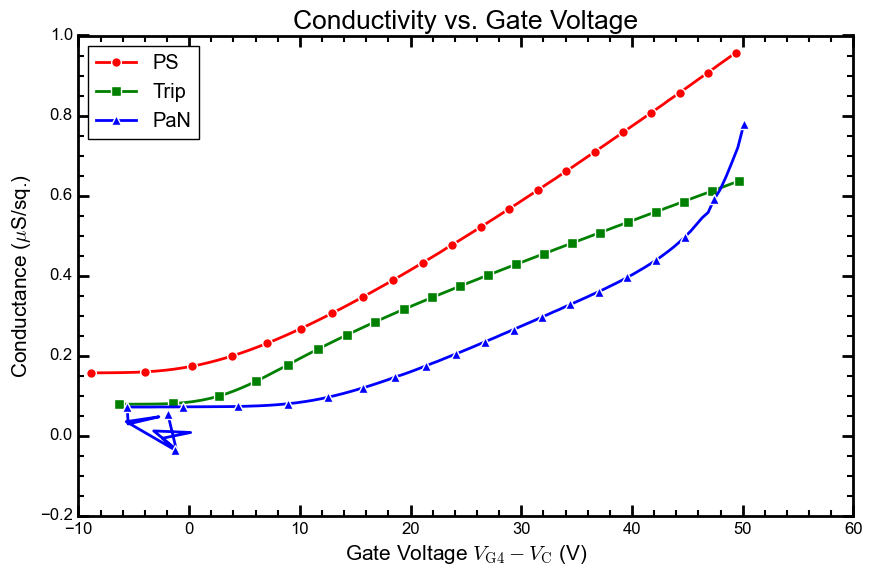

In [74]:

data1 = np.loadtxt("./gvdP/20260512003.dat")
data2 = np.loadtxt("./gvdP/20260512004.dat")
data3 = np.loadtxt("./gvdP/20260512005.dat")

data_list = [data1, data2, data3]

labels = ["PS", "Trip", "PaN"]
colors = ["red", "green", "blue"]
markers = ["o", "s", "^"]
mu_1 = [3.13,1.77,2.03]
V_T_1 = [-1.76,-11.14,7.14]

dataset = list(zip(data_list, labels, colors, markers, mu_1, V_T_1))
for data, label, color, marker, mu, V_T in dataset:
    V_GS = data[:, 0]
    I_DS = data[:, 1]
    V_DS = data[:, 2]
    V_C = 0.5 * (data[:, 4] + data[:, 5])
    V_12 = data[:, 6]
    sigma = -data[:, 7]
    V_del = -(V_GS - V_C)

    plt.plot(
        V_del,
        sigma * 1e6,
        color=color,
        marker=marker,
        markevery=5,
        lw=2,
        ls='-',
        label=label,
        markeredgecolor="white", markeredgewidth=1, markersize=7
    )

plt.xlabel(r"Gate Voltage $V_\text{G4} - V_\text{C}$ (V)")
plt.ylabel(r"Conductance ($\mu$S/sq.)")
# plt.xlim(0,60)
# plt.ylim(0, 0.20)  # Adjust y-axis limits for better visualization
plt.title("Conductivity vs. Gate Voltage", fontsize=19)
plt.legend(numpoints=1, loc='upper left')
plt.show()


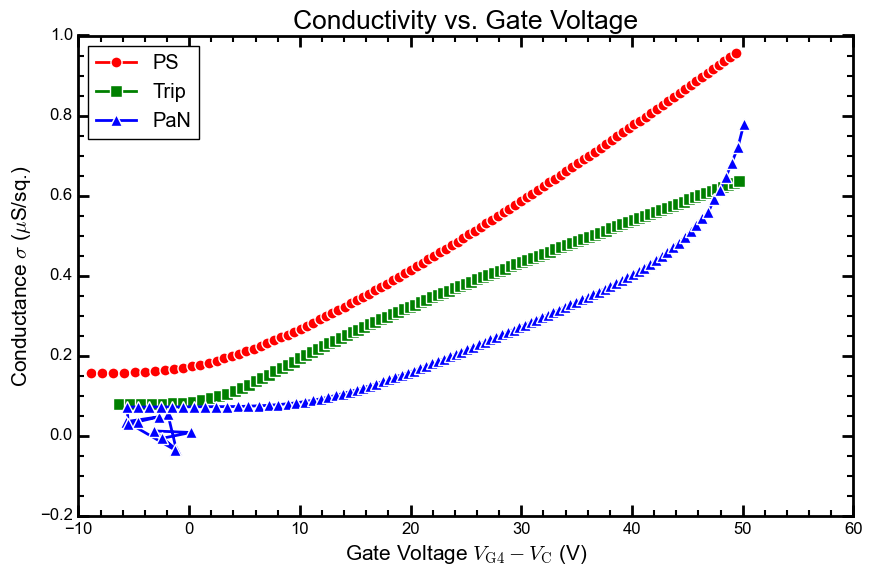

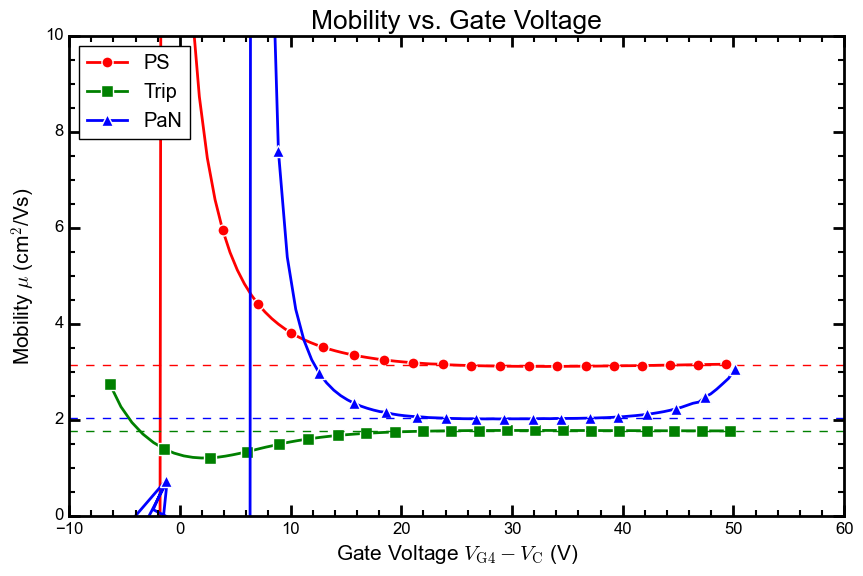

In [75]:
selected_labels = {"PS", "Trip", "PaN"}

plt.figure()
for data, label, color, marker, mu, V_T in dataset:
    if label not in selected_labels:
        continue

    V_GS = data[:, 0]
    V_C = 0.5 * (data[:, 4] + data[:, 5])
    sigma = -data[:, 7]
    V_del = -(V_GS - V_C)

    plt.plot(
        V_del,
        sigma * 1e6,
        color=color,
        marker=marker,
        markevery=1,
        ls='-',
        lw=2,
        label=label,
        markeredgecolor="white",
        markeredgewidth=1,
        markersize=8,
    )

plt.xlabel(r"Gate Voltage $V_\text{G4} - V_\text{C}$ (V)")
plt.ylabel(r"Conductance $\sigma$ ($\mu$S/sq.)")
# plt.xlim(40, 60)
# plt.ylim(0, 0.20)
plt.title("Conductivity vs. Gate Voltage", fontsize=19)
plt.legend(numpoints=1, loc='upper left')
plt.savefig('sigma-1.eps', format='eps')
plt.show()

plt.figure()
for data, label, color, marker, mu, V_T in dataset:
    if label not in selected_labels:
        continue

    V_GS = data[:, 0]
    V_C = 0.5 * (data[:, 4] + data[:, 5])
    sigma = -data[:, 7]
    V_del = -(V_GS - V_C)
    mu_var = sigma / (Ci * (V_del - V_T)) * 1e4

    plt.plot(
        V_del,
        mu_var,
        color=color,
        marker=marker,
        markevery=5,
        ls='-',
        lw=2,
        label=label,
        markeredgecolor="white",
        markeredgewidth=1,
        markersize=8,
    )
    plt.axhline(y=mu, color=color, linestyle='--')

plt.xlabel(r"Gate Voltage $V_\text{G4} - V_\text{C}$ (V)")
plt.ylabel(r"Mobility $\mu$ (cm$^2$/Vs)")
# plt.xlim(40, 60)
plt.ylim(0, 10)
plt.title("Mobility vs. Gate Voltage", fontsize=19)
plt.legend(numpoints=1, loc='upper left')
plt.savefig('muvar-1.eps', format='eps')
plt.show()